# Test IdIE density approximation

In [1]:
from pearsondist import Pearson8
import matplotlib.pyplot as plt

from ajdmom.ito_cond2_mom import moment_IEII, poly2num
from ajdmom.mdl_srjd.euler import rSRJD
import math
import numpy as np
rng = np.random.default_rng()

In [2]:
theta = 0.008
# theta = 0.018
v0, k, sigma = 0.007569, 3.46, 0.14
lmbd, mu_v, h = 0.47, 0.05, 1.0

par = {'v0': v0, 'h': h, 'k': k, 'theta': theta, 'sigma': sigma, 'mu_v': mu_v, 'lmbd': lmbd}

num_jumps = rng.poisson(lmbd * h)
# num_jumps = 1
jumptimes = sorted(rng.uniform(0, h, num_jumps))
jumptimes = [float(jumptime) for jumptime in jumptimes]
jumpsizes = rng.exponential(mu_v, num_jumps)
jumpsizes = [float(jumpsize) for jumpsize in jumpsizes]

par['jumptime'] = jumptimes
par['jumpsize'] = jumpsizes
print(f'jump times: {jumptimes}')
print(f'jump sizes: {jumpsizes}')

jump times: [0.8456401837847797]
jump sizes: [0.012581479461929458]


In [3]:
def IEZ(k, jumptime, jumpsize):
    if len(jumptime) == 0: return 1
    val = 0
    for i in range(len(jumptime)):
        val += math.exp(k * jumptime[i]) * jumpsize[i]
    return val

def IE(v0, k, theta, sigma, t, jumptime, jumpsize, vt):
    mu_ev = v0 - theta + theta * math.exp(k * t)
    mu_ev += IEZ(k, jumptime, jumpsize)
    ie = (math.exp(k * t) * vt - mu_ev) / sigma
    return ie

moms: [0.0, 2.0582280457061275, 2.2086007778123484, 16.344134229805302, 53.83644418177174, 316.99152251230475, 1719.0421878261402, 11291.299847057477]


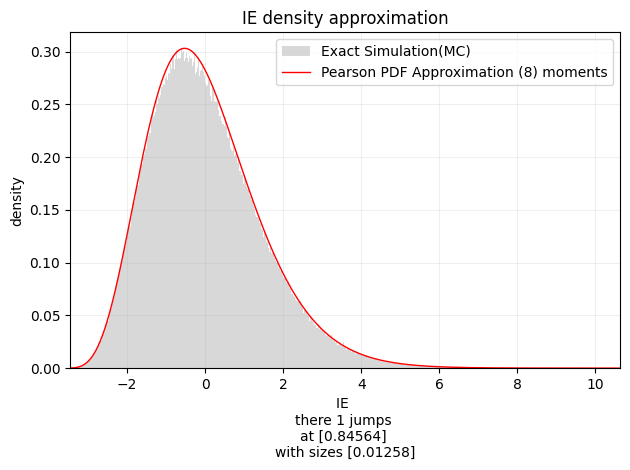

In [6]:
vt = rSRJD(v0, k, theta, sigma, h, jumpsizes, jumptimes, 1000 * 1000)
ie = IE(v0, k, theta, sigma, h, jumptimes, jumpsizes, vt)

moms = [poly2num(moment_IEII(i, 0, 0), par) for i in range(1, 9)]
print(f'moms: {moms}')

ie_max, ie_min = max(ie), min(ie)
ie_grid = np.linspace(ie_min, ie_max, 1000)

pearson = Pearson8(moms[:8])
pdf = pearson.pdf(ie_grid)

hist, bin_edges = np.histogram(ie, bins=1000, density=True)
hist_max = np.max(hist)
# pdf_max = np.max(pdf)
pdf_max = 1
scaling_factor = hist_max / pdf_max
scaled_pdf = pdf * scaling_factor

plt.hist(ie, bins=1000, density=True, alpha=0.3, color='gray', label='Exact Simulation(MC)')
plt.plot(ie_grid, scaled_pdf, 'r-', lw=1, label=f'Pearson PDF Approximation ({len(moms)}) moments')
plt.xlim(-0.002 + ie_min, ie_max)
# plt.ylim()
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.title('IE density approximation')
jumptime = [round(time, 5) for time in jumptimes]
jumpsize = [round(size, 5) for size in jumpsizes]
plt.xlabel(f'IE \nthere {num_jumps} jumps \nat {jumptime} \nwith sizes {jumpsize}')
plt.ylabel('density')
plt.legend()
plt.grid(alpha= 0.2)
plt.tight_layout()
plt.show()